In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F

In [2]:
mnist = fetch_openml('mnist_784', as_frame=False, cache=False)

In [3]:
X = mnist.data.astype('float32')
y = mnist.target.astype('int64')

In [4]:
X /= 255.0

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [6]:
def plot_example(X, y):
    """
    Plot the first 5 images and their labels in a row.
    """
    for i, (img, y) in enumerate(zip(X[:5].reshape(5, 28, 28), y[:5])):
        plt.subplot(151 + i)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.title(y)

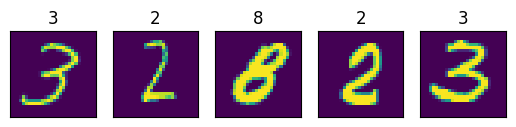

In [7]:
plot_example(X_train, y_train)

In [8]:
# Hyperparams
mnist_dim = X.shape[1]
hidden_dim = int(mnist_dim/8)
output_dim = len(np.unique(mnist.target))

In [10]:
print(mnist_dim, hidden_dim, output_dim)

784 98 10


In [9]:
class ClassifierModule(nn.Module):
    def __init__(self,
                 input_dim=mnist_dim,
                 hidden_dim=hidden_dim,
                 output_dim=output_dim,
                 dropout=0.3):
        super().__init__()

        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, X):
        X = F.relu(self.hidden(X))
        X = self.dropout(X)
        X = F.softmax(self.output(X), dim=-1)
        return X

In [10]:
def train(model, X_train, y_train, X_test, y_test, epochs=10, batch_size=128):
    optimizer = torch.optim.Adam(model.parameters())
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for i in range(0, len(X_train), batch_size):
            X_batch = torch.from_numpy(X_train[i:i+batch_size])
            y_batch = torch.from_numpy(y_train[i:i+batch_size])

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

        # Evaluate on test set
        model.eval()
        with torch.no_grad():
            X_test_tensor = torch.from_numpy(X_test)
            y_test_tensor = torch.from_numpy(y_test)
            test_outputs = model(X_test_tensor)
            _, predicted = torch.max(test_outputs, 1)
            accuracy = (predicted == y_test_tensor).float().mean()
            print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Test Accuracy: {accuracy:.4f}')

In [11]:
net = ClassifierModule()

In [12]:
train(net, X_train, y_train, X_test, y_test)

Epoch 1/10, Loss: 1.6468, Test Accuracy: 0.9131
Epoch 2/10, Loss: 1.6248, Test Accuracy: 0.9291
Epoch 3/10, Loss: 1.5575, Test Accuracy: 0.9391
Epoch 4/10, Loss: 1.5561, Test Accuracy: 0.9464
Epoch 5/10, Loss: 1.5391, Test Accuracy: 0.9503
Epoch 6/10, Loss: 1.4912, Test Accuracy: 0.9539
Epoch 7/10, Loss: 1.4912, Test Accuracy: 0.9549
Epoch 8/10, Loss: 1.4935, Test Accuracy: 0.9580
Epoch 9/10, Loss: 1.4649, Test Accuracy: 0.9597
Epoch 10/10, Loss: 1.4912, Test Accuracy: 0.9610


In [13]:
y_hat = net(torch.from_numpy(X_test))
_, predicted = torch.max(y_hat, 1)

In [14]:
predicted

tensor([8, 4, 8,  ..., 5, 9, 2])

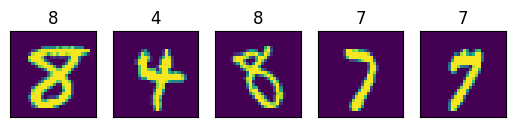

In [15]:
plot_example(X_test, predicted.numpy())

In [16]:
XCnn = X.reshape(-1, 1, 28, 28)

In [17]:
XCnn_train, XCnn_test, y_train, y_test = train_test_split(XCnn, y, test_size=0.25, random_state=42)

In [18]:
class Cnn(nn.Module):
    def __init__(self,
                 dropout=0.3):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3)
        self.conv2_drop = nn.Dropout2d(p=dropout)
        self.fc1 = nn.Linear(800, 100)
        self.fc2 = nn.Linear(100, 10)
        self.fc1_drop = nn.Dropout(p=dropout)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        
        # flatten over channel
        x = x.view(-1, x.size(1) * x.size(2) * x.size(3))
        
        x = F.relu(self.fc1_drop(self.fc1(x)))
        x = F.softmax(self.fc2(x), dim=-1)
        return x

In [19]:
cnn_net = Cnn()

In [20]:
train(cnn_net, XCnn_train, y_train, XCnn_test, y_test)

Epoch 1/10, Loss: 1.5449, Test Accuracy: 0.9495
Epoch 2/10, Loss: 1.4743, Test Accuracy: 0.9623
Epoch 3/10, Loss: 1.5056, Test Accuracy: 0.9718
Epoch 4/10, Loss: 1.4618, Test Accuracy: 0.9747
Epoch 5/10, Loss: 1.4632, Test Accuracy: 0.9766
Epoch 6/10, Loss: 1.4612, Test Accuracy: 0.9785
Epoch 7/10, Loss: 1.4711, Test Accuracy: 0.9816
Epoch 8/10, Loss: 1.4612, Test Accuracy: 0.9823
Epoch 9/10, Loss: 1.4612, Test Accuracy: 0.9836
Epoch 10/10, Loss: 1.4644, Test Accuracy: 0.9832


In [21]:
y_hat = cnn_net(torch.from_numpy(XCnn_test))
_, predicted = torch.max(y_hat, 1)

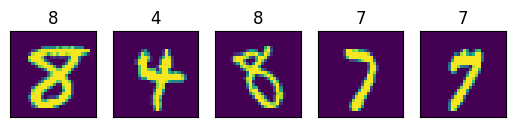

In [22]:
plot_example(X_test, predicted.numpy())